In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [2]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


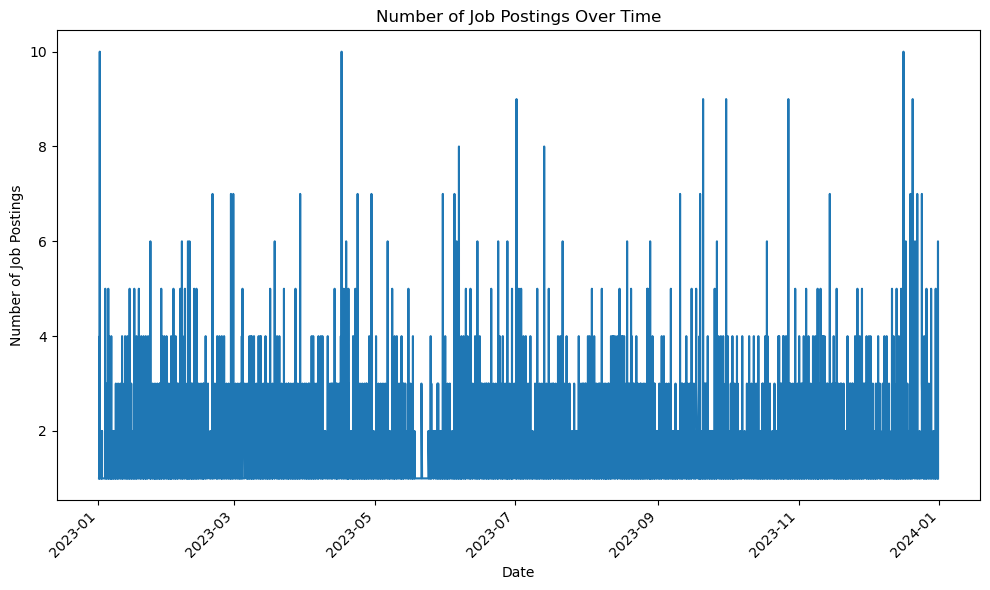

In [3]:
# Data Visualization
plt.figure(figsize=(10, 6))
df['job_posted_date'].head(50000).value_counts().sort_index().plot(kind='line')
plt.title('Number of Job Postings Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [4]:
df[pd.notna(df['salary_year_avg'])]["salary_year_avg"]

28        109500.0
77        140000.0
92        120000.0
100       228222.0
109        89000.0
            ...   
785624    139216.0
785641    150000.0
785648    221875.0
785682    157500.0
785692    157500.0
Name: salary_year_avg, Length: 22003, dtype: float64

In [5]:
df_salary = df[pd.notna(df['salary_year_avg'])][["salary_year_avg"]].copy()

def projected_salary(salary):
    return salary * 1.05

df_salary["salary_year_inflated"] = df_salary["salary_year_avg"].apply(projected_salary)

df_salary[["salary_year_inflated", "salary_year_avg"]]

,salary_year_inflated,salary_year_avg
28,114975.00,109500.0
77,147000.00,140000.0
92,126000.00,120000.0
100,239633.10,228222.0
109,93450.00,89000.0
...,...,...
785624,146176.80,139216.0
785641,157500.00,150000.0
785648,232968.75,221875.0
785682,165375.00,157500.0


In [6]:
# Using Lambda Function
df_salary["salary_year_inflated_lambda"] = df_salary["salary_year_avg"].apply(lambda x: x * 1.05)
df_salary[["salary_year_inflated_lambda", "salary_year_avg"]]

,salary_year_inflated_lambda,salary_year_avg
28,114975.00,109500.0
77,147000.00,140000.0
92,126000.00,120000.0
100,239633.10,228222.0
109,93450.00,89000.0
...,...,...
785624,146176.80,139216.0
785641,157500.00,150000.0
785648,232968.75,221875.0
785682,165375.00,157500.0


In [7]:
# without lambda and apply function
df_salary["salary_year_inflated_no_lambda"] = df_salary["salary_year_avg"] * 1.05
df_salary[["salary_year_inflated_no_lambda", "salary_year_avg"]]

,salary_year_inflated_no_lambda,salary_year_avg
28,114975.00,109500.0
77,147000.00,140000.0
92,126000.00,120000.0
100,239633.10,228222.0
109,93450.00,89000.0
...,...,...
785624,146176.80,139216.0
785641,157500.00,150000.0
785648,232968.75,221875.0
785682,165375.00,157500.0


In [8]:
# This converts job_skills to a list if it's a string, and leaves it as is if it's already a list. It also handles NaN values by returning them unchanged. If the string cannot be parsed as a list, it returns an empty list instead of raising an error.
import ast

def clean_list(x):
    if isinstance(x, list):        # already a list → keep it
        return x
    if pd.isna(x):                 # handle NaN
        return []
    if isinstance(x, str):         # string → convert
        try:
            return ast.literal_eval(x)
        except:
            return []
    return []

df['job_skills'] = df['job_skills'].apply(clean_list)

In [9]:
df["job_skills"].head(10)

0                                                   []
1           [r, python, sql, nosql, power bi, tableau]
2    [python, sql, c#, azure, airflow, dax, docker,...
3    [python, c++, java, matlab, aws, tensorflow, k...
4    [bash, python, oracle, aws, ansible, puppet, j...
5                                   [python, sql, gcp]
6    [sql, python, java, sql server, gcp, bigquery,...
7    [sql, nosql, gcp, azure, aws, bigquery, databr...
8                        [excel, powerpoint, power bi]
9    [sql, python, r, mongodb, mongodb, sql server,...
Name: job_skills, dtype: object

In [10]:
type(df["job_skills"][0])

list

In [15]:
def projected_salary(row):
    if "Senior" in row["job_title_short"]:
        return row["salary_year_avg"] * 1.05
    else:
        return row["salary_year_avg"] * 1.03

df["salary_year_inflated_conditional"] = df.apply(projected_salary, axis=1)

df[["salary_year_inflated_conditional", "salary_year_avg"]]
df[pd.notna(df["salary_year_inflated_conditional"])][["salary_year_inflated_conditional", "salary_year_avg"]]

,salary_year_inflated_conditional,salary_year_avg
28,112785.00,109500.0
77,144200.00,140000.0
92,123600.00,120000.0
100,235068.66,228222.0
109,91670.00,89000.0
...,...,...
785624,143392.48,139216.0
785641,154500.00,150000.0
785648,228531.25,221875.0
785682,162225.00,157500.0


In [17]:
df["inflated_salary_lambda"] = df.apply(lambda row: row["salary_year_avg"] * 1.05 if "Senior" in row["job_title_short"] else row["salary_year_avg"] * 1.03, axis=1)
df[pd.notna(df["inflated_salary_lambda"])][["inflated_salary_lambda", "salary_year_avg"]]

,inflated_salary_lambda,salary_year_avg
28,112785.00,109500.0
77,144200.00,140000.0
92,123600.00,120000.0
100,235068.66,228222.0
109,91670.00,89000.0
...,...,...
785624,143392.48,139216.0
785641,154500.00,150000.0
785648,228531.25,221875.0
785682,162225.00,157500.0


In [19]:
type(df['job_skills'][0])

list

In [21]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,salary_year_inflated_conditional,inflated_salary_lambda
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,[],NaN,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",NaN,NaN
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",NaN,NaN
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",NaN,NaN
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete...",NaN,NaN
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi...",NaN,NaN
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}",NaN,NaN
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh...",NaN,NaN


In [24]:
# The job_type_skill column contains string representations of dictionaries, which we want to convert to actual dictionaries. We can use a similar approach as with the job_skills column, but we need to handle the case where the string is not a valid dictionary. Here's how you can do it:
def clean_dict(x):
    if isinstance(x, dict):        # already a dict → keep it
        return x
    if pd.isna(x):                 # handle NaN
        return {}
    if isinstance(x, str):         # string → convert
        try:
            return ast.literal_eval(x)
        except:
            return {}
    return {}

df['job_type_skills'] = df['job_type_skills'].apply(clean_dict)


In [25]:
df["job_type_skills"].head(10)

0                                                   {}
1    {'analyst_tools': ['power bi', 'tableau'], 'pr...
2    {'analyst_tools': ['dax'], 'cloud': ['azure'],...
3    {'cloud': ['aws'], 'libraries': ['tensorflow',...
4    {'cloud': ['oracle', 'aws'], 'other': ['ansibl...
5    {'cloud': ['gcp'], 'programming': ['python', '...
6    {'cloud': ['gcp', 'bigquery'], 'databases': ['...
7    {'cloud': ['gcp', 'azure', 'aws', 'bigquery', ...
8    {'analyst_tools': ['excel', 'powerpoint', 'pow...
9    {'analyst_tools': ['excel'], 'cloud': ['azure'...
Name: job_type_skills, dtype: object